In [65]:
#import req libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
df=pd.read_csv('amazon_laptop_price_dataset.csv')

In [67]:
#convert usd price to ind rs
df['Price_USD'] = pd.to_numeric(df['Price_USD'], errors='coerce')
df['Price_INR'] = df['Price_USD'] * 90.94
df.head()

,Brand,Processor,RAM_GB,Storage_GB,Operating_System,GPU,Rating,Price_USD,Price_INR
0,MSI,AMD Ryzen 3,4,512,macOS,AMD Radeon,4.2,1092.04,99310.1176
1,Lenovo,Intel i7,32,128,macOS,NVIDIA GTX 1650,3.1,1934.84,175954.3496
2,Asus,AMD Ryzen 7,8,256,Windows 10,Integrated,3.6,758.86,69010.7284
3,Dell,Intel i7,16,512,Windows 11,AMD Radeon,3.6,1430.88,130124.2272
4,MSI,AMD Ryzen 7,8,512,Windows 11,NVIDIA RTX 3050,3.8,1457.77,132569.6038


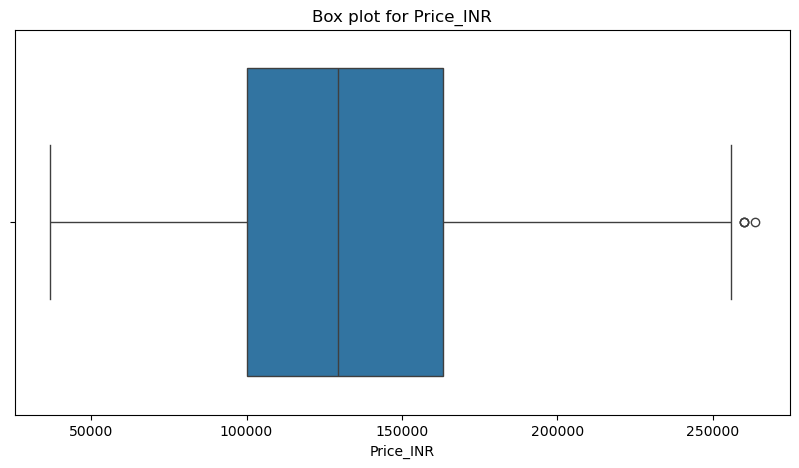

In [68]:
#check for outliers using box plot
plt.figure(figsize=(10,5))
sns.boxplot(x=df['Price_INR'])
plt.title("Box plot for Price_INR")
plt.show()

In [69]:
#find outliers using IQR method
Q1 = df['Price_INR'].quantile(0.25)
Q3 = df['Price_INR'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Price_INR'] < lower_bound) | (df['Price_INR'] > upper_bound)]
outliers

,Brand,Processor,RAM_GB,Storage_GB,Operating_System,GPU,Rating,Price_USD,Price_INR
101,Apple,Intel i7,16,1024,macOS,NVIDIA RTX 3050,4.1,2859.64,260055.6616
598,Apple,Intel i7,32,1024,macOS,Integrated,4.5,2896.85,263439.5390
617,Apple,AMD Ryzen 7,32,1024,macOS,Integrated,5.0,2860.19,260105.6786
865,HP,Intel i7,32,1024,macOS,NVIDIA RTX 3050,3.1,2858.59,259960.1746


In [70]:
#drop outliers
df = df[(df['Price_INR'] >= lower_bound) & (df['Price_INR'] <= upper_bound)]

In [71]:
#drop price_usd column
df.drop(['Price_USD'],axis=1,inplace=True)

In [72]:
# unique values
print("Unique values in Brand column:", df['Brand'].value_counts())
print("Unique values in Processor column:", df['Processor'].value_counts())
print("Unique values in RAM_GB column:", df['RAM_GB'].value_counts())
print("Unique values in Storage_GB column:", df['Storage_GB'].value_counts())
print("Unique values in OS column:", df['Operating_System'].value_counts())
print("Unique values in GPU column:", df['GPU'].value_counts())

Unique values in Brand column: Brand
Apple     154
MSI       149
Asus      144
Dell      144
Acer      142
HP        132
Lenovo    131
Name: count, dtype: int64
Unique values in Processor column: Processor
AMD Ryzen 7    182
Intel i5       176
AMD Ryzen 5    173
AMD Ryzen 3    158
Intel i7       157
Intel i3       150
Name: count, dtype: int64
Unique values in RAM_GB column: RAM_GB
8     263
16    254
32    252
4     227
Name: count, dtype: int64
Unique values in Storage_GB column: Storage_GB
128     280
512     262
256     233
1024    221
Name: count, dtype: int64
Unique values in OS column: Operating_System
Windows 11    345
Windows 10    326
macOS         325
Name: count, dtype: int64
Unique values in GPU column: GPU
Integrated         277
AMD Radeon         268
NVIDIA RTX 3050    244
NVIDIA GTX 1650    207
Name: count, dtype: int64


In [73]:
#display only operating system of macos and windows
df = df[df['Operating_System'].isin(['macOS', 'Windows 10', 'Windows 11'])]


In [74]:
#convert processor to numeric values
df['Processor'] = df['Processor'].replace({'Intel i3': 1, 'Intel i5': 2, 'Intel i7': 3, 'AMD Ryzen 3': 1, 'AMD Ryzen 5': 2, 'AMD Ryzen 7': 3})
print(df['Processor'].value_counts())


Processor
2    349
3    339
1    308
Name: count, dtype: int64


C:\Users\saiko\AppData\Local\Temp\ipykernel_22416\4010745922.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Processor'] = df['Processor'].replace({'Intel i3': 1, 'Intel i5': 2, 'Intel i7': 3, 'AMD Ryzen 3': 1, 'AMD Ryzen 5': 2, 'AMD Ryzen 7': 3})


In [75]:
df['GPU'] = df['GPU'].replace({'Integrated':0,'AMD Radeon':1,'NVIDIA GTX 1650':2,'NVIDIA RTX 3050':3})
df['GPU'].value_counts()

C:\Users\saiko\AppData\Local\Temp\ipykernel_22416\1937684147.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['GPU'] = df['GPU'].replace({'Integrated':0,'AMD Radeon':1,'NVIDIA GTX 1650':2,'NVIDIA RTX 3050':3})


GPU
0    277
1    268
3    244
2    207
Name: count, dtype: int64

In [76]:
# brand column encoding using one hot encoding
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

brand_encoded = encoder.fit_transform(df[['Brand']])

brand_encoded

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(996, 7))

In [77]:
# convert encoded array into dataframe with column names
brand_encoded_df = pd.DataFrame(
    brand_encoded,
    columns=encoder.get_feature_names_out(['Brand'])
)

# reset index to avoid alignment issue
df = df.reset_index(drop=True)
brand_encoded_df = brand_encoded_df.reset_index(drop=True)

# concatenate encoded columns to original dataframe
df = pd.concat([df, brand_encoded_df], axis=1)

df.head()

,Brand,Processor,RAM_GB,Storage_GB,Operating_System,GPU,Rating,Price_INR,Brand_Acer,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI
0,MSI,1,4,512,macOS,1,4.2,99310.1176,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,Lenovo,3,32,128,macOS,2,3.1,175954.3496,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,Asus,3,8,256,Windows 10,0,3.6,69010.7284,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,Dell,3,16,512,Windows 11,1,3.6,130124.2272,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,MSI,3,8,512,Windows 11,3,3.8,132569.6038,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [78]:
# drop original brand column 
df = df.drop('Brand', axis=1)

df.head()

,Processor,RAM_GB,Storage_GB,Operating_System,GPU,Rating,Price_INR,Brand_Acer,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI
0,1,4,512,macOS,1,4.2,99310.1176,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,3,32,128,macOS,2,3.1,175954.3496,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,3,8,256,Windows 10,0,3.6,69010.7284,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,3,16,512,Windows 11,1,3.6,130124.2272,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,3,8,512,Windows 11,3,3.8,132569.6038,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [79]:
# Convert Operating_System to numeric
df['Operating_System'] = df['Operating_System'].replace({
    'Windows 10': 1,
    'Windows 11': 2,
    'macOS': 3
})


C:\Users\saiko\AppData\Local\Temp\ipykernel_22416\3989825256.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Operating_System'] = df['Operating_System'].replace({


In [80]:
#divide data into x and y
X = df.drop(['Price_INR'], axis=1)
y = df['Price_INR']

In [81]:
#split data into train and test 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [82]:
print(X.dtypes)

Processor             int64
RAM_GB                int64
Storage_GB            int64
Operating_System      int64
GPU                   int64
Rating              float64
Brand_Acer          float64
Brand_Apple         float64
Brand_Asus          float64
Brand_Dell          float64
Brand_HP            float64
Brand_Lenovo        float64
Brand_MSI           float64
dtype: object


In [83]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [84]:
#mse
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 106536071.1288538


In [85]:
#mae
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 8608.135857109044


In [86]:
#r2
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

R-squared: 0.9492507867233846


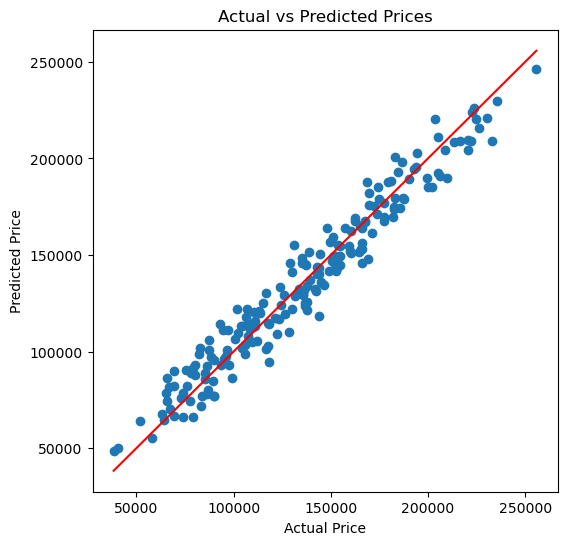

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()